In [ ]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Definir los directorios de origen y destino
src_folder = "spectrums"
dst_folder = "spectrums training 100k"

# Crear la carpeta de destino si no existe
if not os.path.exists(dst_folder):
    os.makedirs(dst_folder)

# Listar todos los archivos .fits en el directorio de origen
fits_files = [f for f in os.listdir(src_folder) if f.lower().endswith(".fits")]

# Seleccionar 100000 archivos aleatorios
selected_files = random.sample(fits_files, 100000)

# Definir los rangos de redshift deseados
bin_ranges = [(0, 0.1), (0.1, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]

# Diccionario para llevar el conteo en cada rango
bin_counts = {br: 0 for br in bin_ranges}

# Diccionario con mínimos distintos para cada rango

# 0-1 hay > 100000
# 1-2 hay > 100000
# 2-3 hay > 100000
# 3-4 hay 35894
# 4-5 hay 2529
# 5-6 hay 900
# 6-7 hay 854
# 7-8 hay 245

min_required_values = {
    (0, 0.1): 20000,
    (0.1, 1): 15000,
    (1, 2): 20000,
    (2, 3): 15000,
    (3, 4): 5000,
    (4, 5): 2000,
    (5, 6): 900,
    (6, 7): 854,
    (7, 8): 245
}

# Lista para almacenar los valores de redshift y usarlos en el histograma
redshift_values = []

# Copiar archivos y extraer el valor de redshift de cada uno
for file in selected_files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    
    # Copiar el archivo
    shutil.copy(src_path, dst_path)
    print(f"Copiado: {file}")
    
    # Extraer el valor de redshift
    try:
        with fits.open(src_path) as hdul:
            redshift = hdul[2].data["Z"][0]
            redshift_values.append(redshift)
            # Determinar en qué rango cae el redshift y actualizar el conteo
            for br in bin_ranges:
                lower, upper = br
                if lower <= redshift < upper:
                    bin_counts[br] += 1
                    break
    except Exception as e:
        print(f"Error procesando {file}: {e}")

# Imprimir un reporte individual para cada rango con su mínimo respectivo
print("\nConteo por rangos de redshift:")
for br in bin_ranges:
    lower, upper = br
    count = bin_counts[br]
    min_required = min_required_values.get(br, 0)
    if count >= min_required:
        print(f"Rango {lower} - {upper}: {count} archivos (cumple con el mínimo de {min_required})")
    else:
        print(f"Rango {lower} - {upper}: {count} archivos (NO cumple con el mínimo de {min_required})")

Copiado: spec-4260-55478-0544.fits
Copiado: spec-7434-57166-0275.fits
Copiado: spec-5314-55952-0155.fits
Copiado: spec-2519-54570-0629.fits
Copiado: spec-11295-58456-0481.fits
Copiado: spec-7114-56748-0087.fits
Copiado: spec-3787-55565-0084.fits
Copiado: spec-6835-56420-0346.fits
Copiado: spec-1334-52764-0501.fits
Copiado: spec-1300-52973-0622.fits
Copiado: spec-1583-52941-0485.fits
Copiado: spec-5961-56460-0209.fits
Copiado: spec-6497-56329-0936.fits
Copiado: spec-5899-56038-0531.fits
Copiado: spec-5131-55835-0810.fits
Copiado: spec-4035-55383-0139.fits
Copiado: spec-5140-55836-0638.fits
Copiado: spec-0756-52577-0346.fits
Copiado: spec-0587-52026-0333.fits
Copiado: spec-5046-56243-0971.fits
Copiado: spec-2094-53851-0618.fits
Copiado: spec-5894-56039-0761.fits
Copiado: spec-1620-53137-0507.fits
Copiado: spec-0964-52646-0413.fits
Copiado: spec-5031-56209-0995.fits
Copiado: spec-8299-57346-0919.fits
Copiado: spec-6141-56210-0211.fits
Copiado: spec-7407-56772-0117.fits
Copiado: spec-5194-

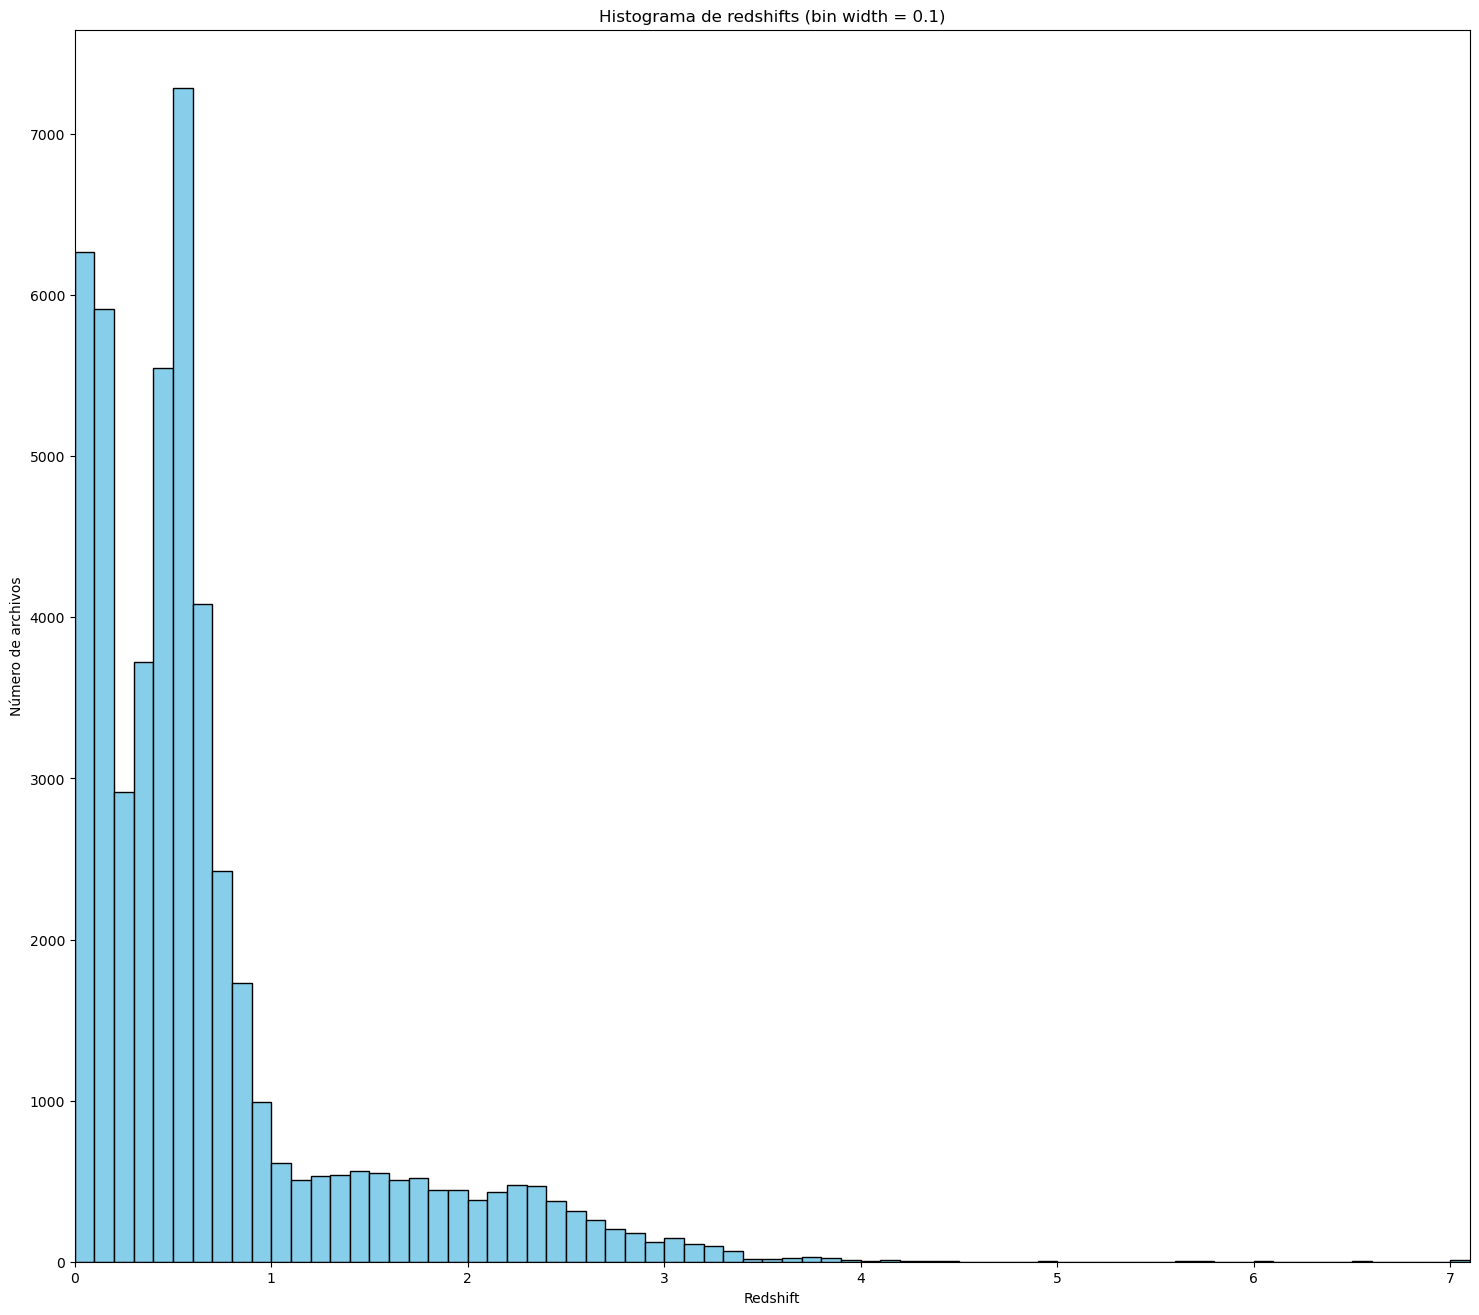

In [ ]:
# Definir los bordes de los bins para el histograma usando los rangos definidos
bin_edges = [br[0] for br in bin_ranges] + [bin_ranges[-1][1]]

# Crear el histograma
plt.figure(figsize=(18,16))
n, bins_hist, patches = plt.hist(redshift_values, bins=bin_edges, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de archivos")
plt.title("Histograma de redshifts (bins definidos manualmente)")

# Dibujar líneas horizontales de referencia para cada rango con el mínimo requerido
for br in bin_ranges:
    lower, upper = br
    min_required = min_required_values.get(br, 0)
    # Dibujar una línea horizontal que cubre el rango del bin
    plt.hlines(y=min_required, xmin=lower, xmax=upper, colors='red', linestyles='dashed', linewidth=2)
    # Anotar el valor mínimo en el centro del rango
    x_center = (lower + upper) / 2
    plt.text(x_center, min_required + 1, f"min: {min_required}", color='red', ha='center', va='bottom')

plt.xlim(0, 7.1)
plt.show()